# Exploratory Data Analysis & Statistical Insights

## 1. Project Overview

This project performs exploratory data analysis and statistical analysis on an e-commerce sales dataset.

The objective is to uncover business patterns by studying descriptive statistics, distributions, relationships between numerical variables, and differences across business categories.

### Analysis Areas

- Descriptive statistics
- Histogram distributions
- Box plot analysis
- Correlation analysis
- Multivariate visualization
- Business hypothesis testing
- Key business findings

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display plots inside the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load cleaned dataset

from google.colab import files

uploaded = files.upload()

Saving clean_dataset (1).csv to clean_dataset (1).csv


In [3]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 73699
Columns: 24


,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,...,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by,year,month,month_name,estimated_profit,estimated_profit_margin_pct
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,MAHARASHTRA,400081,IN,False,Easy Ship,2022,4,April,129.524,20.0
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,KARNATAKA,560085,IN,False,Easy Ship,2022,4,April,81.200,20.0
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,MAHARASHTRA,410210,IN,True,Unknown,2022,4,April,65.800,20.0
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,PUDUCHERRY,605008,IN,False,Easy Ship,2022,4,April,150.666,20.0
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,TAMIL NADU,600073,IN,False,Unknown,2022,4,April,114.800,20.0


## 2. Dataset Overview

The cleaned e-commerce dataset contains 73,699 records and 24 variables. Before performing statistical analysis, the structure, data types, missing values, and duplicate records are reviewed.

In [4]:
# Dataset overview

print("=== DATASET INFORMATION ===")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print("Total missing values:", df.isnull().sum().sum())

print("\n=== DUPLICATE RECORDS ===")
print("Duplicate rows:", df.duplicated().sum())

=== DATASET INFORMATION ===
Rows: 73699
Columns: 24

=== DATA TYPES ===
index                            int64
order_id                        object
date                            object
status                          object
fulfilment                      object
sales_channel                   object
ship_service_level              object
category                        object
size                            object
courier_status                  object
qty                              int64
currency                        object
amount                         float64
ship_city                       object
ship_state                      object
ship_postal_code                 int64
ship_country                    object
b2b                               bool
fulfilled_by                    object
year                             int64
month                            int64
month_name                      object
estimated_profit               float64
estimated_profit_margin_pct    

In [5]:
# Numerical columns available for statistical analysis

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_cols)

Numerical columns:
['index', 'qty', 'amount', 'ship_postal_code', 'year', 'month', 'estimated_profit', 'estimated_profit_margin_pct']


## 3. Descriptive Statistics

Descriptive statistics are used to understand the central tendency and variability of the main numerical business measures.

The analysis focuses on order quantity, sales amount, estimated profit, and estimated profit margin.

In [6]:
# Descriptive statistics

analysis_cols = [
    "qty",
    "amount",
    "estimated_profit",
    "estimated_profit_margin_pct"
]

descriptive_stats = df[analysis_cols].describe().T

descriptive_stats = descriptive_stats.rename(columns={
    "50%": "median"
})

display(descriptive_stats.round(2))

,count,mean,std,min,25%,median,75%,max
qty,73699.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
amount,73699.0,641.71,255.96,0.0,459.0,605.0,771.0,1239.0
estimated_profit,73699.0,128.34,51.19,0.0,91.8,121.0,154.2,247.8
estimated_profit_margin_pct,73699.0,19.63,2.70,0.0,20.0,20.0,20.0,20.0


## 4. Distribution Analysis

Histograms are used to examine the distribution of order quantity, sales amount, estimated profit, and estimated profit margin. They help identify concentration, skewness, and unusual values.

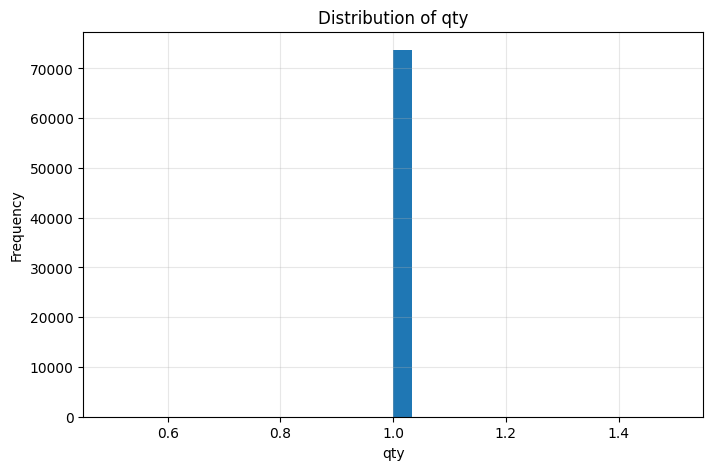

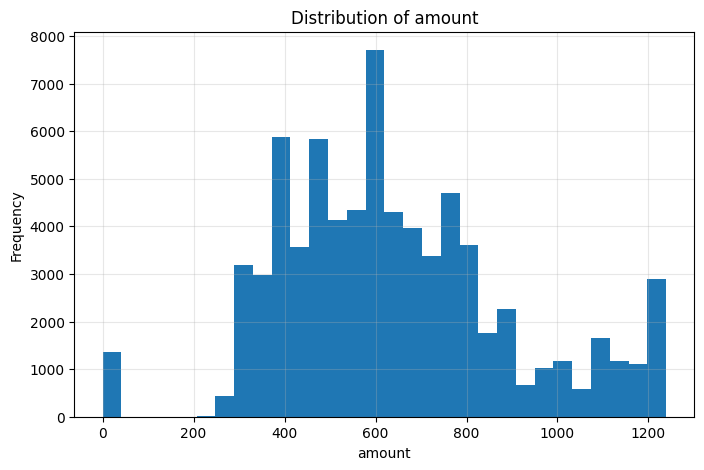

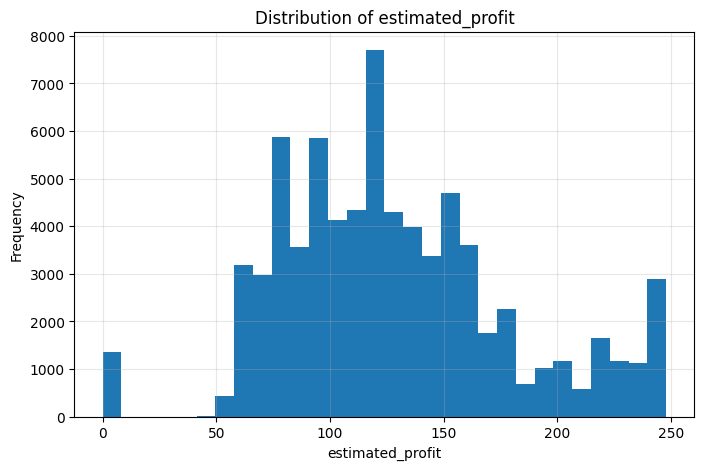

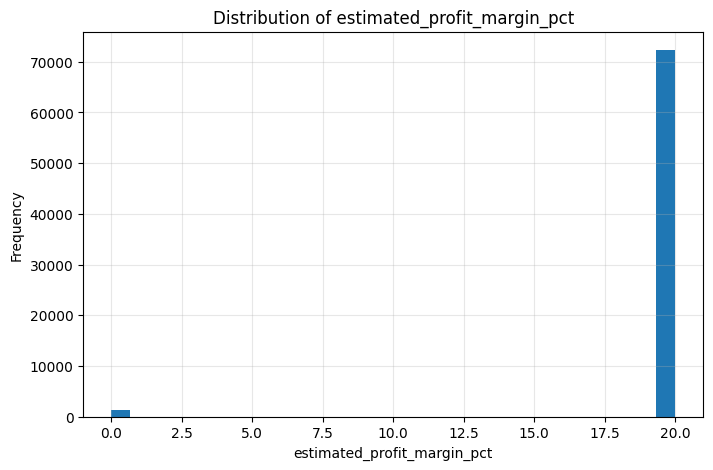

In [7]:
# Histogram distributions

plot_cols = [
    "qty",
    "amount",
    "estimated_profit",
    "estimated_profit_margin_pct"
]

for col in plot_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.show()

## 5. Outlier Analysis

Box plots are used to examine the spread of numerical variables and identify potential outliers using the interquartile range (IQR).

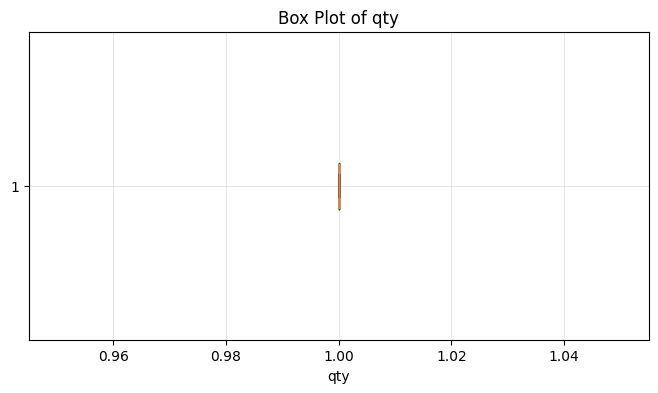

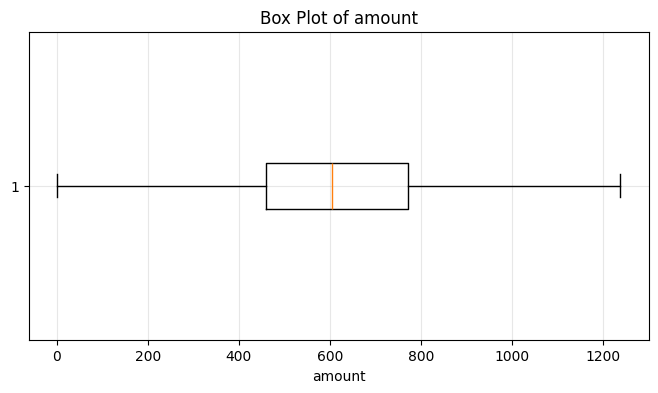

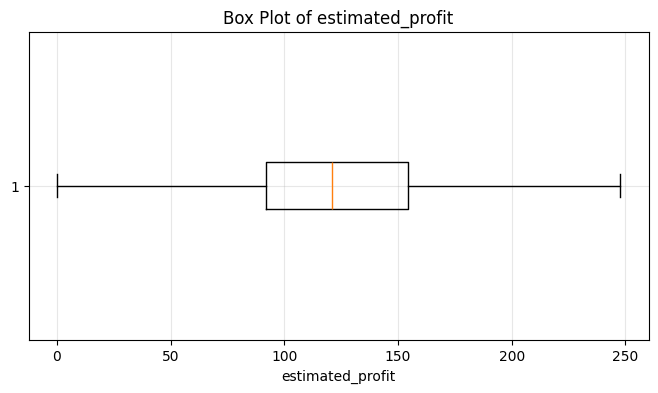

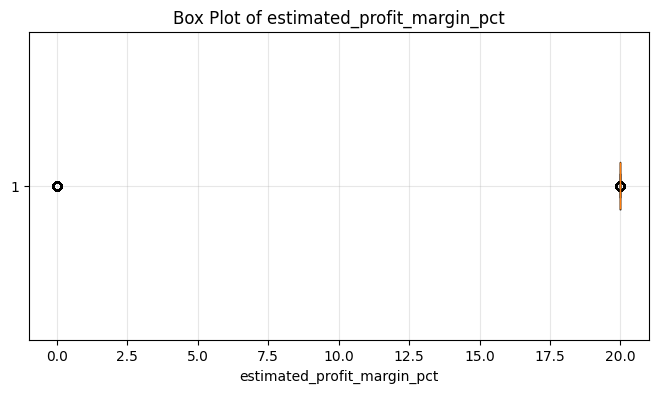

In [8]:
# Box plots for numerical variables

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.grid(alpha=0.3)
    plt.show()

In [9]:
# Count potential outliers using the IQR method

outlier_summary = {}

for col in plot_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_summary[col] = outliers

print("Potential outliers by variable:")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

Potential outliers by variable:
qty: 0
amount: 0
estimated_profit: 0
estimated_profit_margin_pct: 8174


## 6. Correlation Analysis

Correlation analysis is used to examine the strength and direction of linear relationships between numerical variables.

A correlation value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship. Values close to 0 indicate a weak linear relationship.

Correlation does not imply causation.

In [10]:
# Correlation matrix

correlation_cols = [
    "qty",
    "amount",
    "estimated_profit",
    "estimated_profit_margin_pct"
]

correlation_matrix = df[correlation_cols].corr()

display(correlation_matrix.round(2))

,qty,amount,estimated_profit,estimated_profit_margin_pct
qty,NaN,NaN,NaN,NaN
amount,NaN,1.00,1.00,0.34
estimated_profit,NaN,1.00,1.00,0.34
estimated_profit_margin_pct,NaN,0.34,0.34,1.00


,amount,estimated_profit,estimated_profit_margin_pct
amount,1.00,1.00,0.34
estimated_profit,1.00,1.00,0.34
estimated_profit_margin_pct,0.34,0.34,1.00


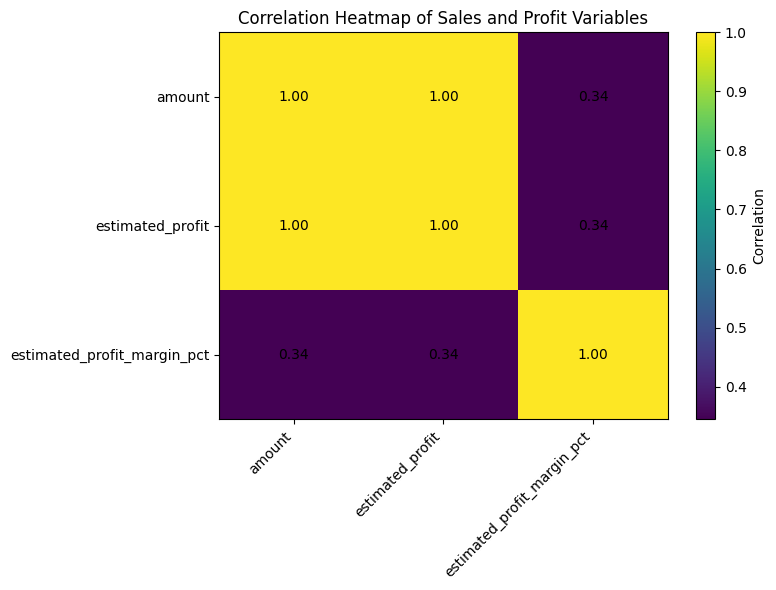

In [12]:
# Correlation analysis excluding constant variables

correlation_cols = [
    "amount",
    "estimated_profit",
    "estimated_profit_margin_pct"
]

correlation_matrix = df[correlation_cols].corr()

display(correlation_matrix.round(2))

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, aspect="auto")

plt.xticks(
    range(len(correlation_cols)),
    correlation_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_cols)),
    correlation_cols
)

plt.colorbar(label="Correlation")

plt.title("Correlation Heatmap of Sales and Profit Variables")

for i in range(len(correlation_cols)):
    for j in range(len(correlation_cols)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [13]:
# Explore categorical variables for hypothesis testing

categorical_cols = [
    "status",
    "fulfilment",
    "sales_channel",
    "ship_service_level",
    "category",
    "courier_status",
    "size",
    "ship_state"
]

for col in categorical_cols:
    print(f"\n=== {col.upper()} ===")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(10))


=== STATUS ===
Unique values: 13
status
Shipped                          42761
Shipped - Delivered to Buyer     17254
Cancelled                        10434
Shipped - Returned to Seller      1165
Shipped - Picked Up                961
Pending                            653
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      134
Shipped - Out for Delivery          35
Shipping                             8
Name: count, dtype: int64

=== FULFILMENT ===
Unique values: 2
fulfilment
Amazon      49385
Merchant    24314
Name: count, dtype: int64

=== SALES_CHANNEL ===
Unique values: 2
sales_channel
Amazon.in     73623
Non-Amazon       76
Name: count, dtype: int64

=== SHIP_SERVICE_LEVEL ===
Unique values: 2
ship_service_level
Expedited    48771
Standard     24928
Name: count, dtype: int64

=== CATEGORY ===
Unique values: 9
category
T-shirt     28348
Shirt       28110
Blazzer      9360
Trousers     6241
Perfume       653
Wallet        572
Socks         315
Shoes          

## 7. Business Hypothesis Testing

### Hypothesis 1: Shipping Service Level and Order Value

**Business question:** Do Expedited and Standard orders have different sales amounts?

**Null hypothesis (H₀):** The distribution of sales amount is the same for Expedited and Standard orders.

**Alternative hypothesis (H₁):** The distribution of sales amount differs between Expedited and Standard orders.

Because sales amounts may not follow a normal distribution, the Mann–Whitney U test is used to compare the two independent groups.

**Significance level:** α = 0.05

In [14]:
from scipy.stats import mannwhitneyu

# Separate sales amounts by shipping service level
expedited = df.loc[
    df["ship_service_level"] == "Expedited",
    "amount"
].dropna()

standard = df.loc[
    df["ship_service_level"] == "Standard",
    "amount"
].dropna()

# Mann-Whitney U test
u_stat, p_value = mannwhitneyu(
    expedited,
    standard,
    alternative="two-sided"
)

print("=== HYPOTHESIS 1: SERVICE LEVEL VS SALES AMOUNT ===")
print(f"Expedited orders: {len(expedited):,}")
print(f"Standard orders: {len(standard):,}")
print(f"Expedited median amount: {expedited.median():.2f}")
print(f"Standard median amount: {standard.median():.2f}")
print(f"Mann-Whitney U statistic: {u_stat:,.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Reject H₀.")
    print("There is a statistically significant difference in sales amount between the two service levels.")
else:
    print("\nResult: Fail to reject H₀.")
    print("There is no statistically significant difference in sales amount between the two service levels.")

=== HYPOTHESIS 1: SERVICE LEVEL VS SALES AMOUNT ===
Expedited orders: 48,771
Standard orders: 24,928
Expedited median amount: 605.00
Standard median amount: 605.00
Mann-Whitney U statistic: 638,266,201.50
P-value: 0.000000

Result: Reject H₀.
There is a statistically significant difference in sales amount between the two service levels.


### H1 Result and Interpretation

The Mann–Whitney U test produced a p-value below 0.05. Therefore, the null hypothesis is rejected.

Although both Expedited and Standard orders have the same median sales amount of ₹605, their overall sales-amount distributions are statistically different.

This suggests that shipping service level is associated with differences in the distribution of order values. However, statistical significance does not necessarily imply a large practical or financial effect.

## 8. Business Hypothesis 2: Fulfilment and Sales Amount

**Business question:** Do Amazon-fulfilled and Merchant-fulfilled orders have different sales amounts?

**Null hypothesis (H₀):** The distribution of sales amount is the same for Amazon and Merchant fulfilment.

**Alternative hypothesis (H₁):** The distribution of sales amount differs between Amazon and Merchant fulfilment.

The Mann–Whitney U test is used because the two fulfilment groups are independent and sales amounts may not follow a normal distribution.

**Significance level:** α = 0.05

In [15]:
# Separate sales amounts by fulfilment type

amazon_fulfilment = df.loc[
    df["fulfilment"] == "Amazon",
    "amount"
].dropna()

merchant_fulfilment = df.loc[
    df["fulfilment"] == "Merchant",
    "amount"
].dropna()

# Mann-Whitney U test

u_stat, p_value = mannwhitneyu(
    amazon_fulfilment,
    merchant_fulfilment,
    alternative="two-sided"
)

print("=== HYPOTHESIS 2: FULFILMENT VS SALES AMOUNT ===")
print(f"Amazon-fulfilled orders: {len(amazon_fulfilment):,}")
print(f"Merchant-fulfilled orders: {len(merchant_fulfilment):,}")

print(f"Amazon median amount: {amazon_fulfilment.median():.2f}")
print(f"Merchant median amount: {merchant_fulfilment.median():.2f}")

print(f"Mann-Whitney U statistic: {u_stat:,.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Reject H₀.")
    print("There is a statistically significant difference in sales amount between Amazon and Merchant fulfilment.")
else:
    print("\nResult: Fail to reject H₀.")
    print("There is no statistically significant difference in sales amount between Amazon and Merchant fulfilment.")

=== HYPOTHESIS 2: FULFILMENT VS SALES AMOUNT ===
Amazon-fulfilled orders: 49,385
Merchant-fulfilled orders: 24,314
Amazon median amount: 605.00
Merchant median amount: 605.00
Mann-Whitney U statistic: 613,296,380.00
P-value: 0.000002

Result: Reject H₀.
There is a statistically significant difference in sales amount between Amazon and Merchant fulfilment.


### H2 Result and Interpretation

The Mann–Whitney U test produced a p-value of 0.000002, which is below the significance level of 0.05. Therefore, the null hypothesis is rejected.

Although Amazon-fulfilled and Merchant-fulfilled orders have the same median sales amount of ₹605, their overall sales-amount distributions differ significantly.

This indicates that fulfilment type is statistically associated with differences in order-value distribution. The result should not be interpreted as proof that fulfilment type causes higher or lower sales.

## 9. Business Hypothesis 3: Fulfilment and Cancellation Rate

**Business question:** Does the cancellation rate differ between Amazon-fulfilled and Merchant-fulfilled orders?

**Null hypothesis (H₀):** The cancellation rate is the same for Amazon and Merchant fulfilment.

**Alternative hypothesis (H₁):** The cancellation rate differs between Amazon and Merchant fulfilment.

A Chi-square test of independence is used because both variables are categorical.

In [16]:
from scipy.stats import chi2_contingency

# Create cancellation indicator
df["is_cancelled"] = (
    df["status"].str.strip().str.lower() == "cancelled"
)

# Contingency table
contingency_table = pd.crosstab(
    df["fulfilment"],
    df["is_cancelled"]
)

print("=== CONTINGENCY TABLE ===")
display(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

# Cancellation rates
cancellation_rates = (
    df.groupby("fulfilment")["is_cancelled"]
      .mean()
      .mul(100)
)

print("\n=== HYPOTHESIS 3: FULFILMENT VS CANCELLATION ===")

for group, rate in cancellation_rates.items():
    print(f"{group} cancellation rate: {rate:.2f}%")

print(f"\nChi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: Reject H₀.")
    print("Cancellation rate differs significantly between Amazon and Merchant fulfilment.")
else:
    print("\nResult: Fail to reject H₀.")
    print("No statistically significant difference in cancellation rate was detected.")

=== CONTINGENCY TABLE ===


is_cancelled,False,True
fulfilment,,
Amazon,43179,6206
Merchant,20086,4228



=== HYPOTHESIS 3: FULFILMENT VS CANCELLATION ===
Amazon cancellation rate: 12.57%
Merchant cancellation rate: 17.39%

Chi-square statistic: 311.39
Degrees of freedom: 1
P-value: 0.000000

Result: Reject H₀.
Cancellation rate differs significantly between Amazon and Merchant fulfilment.


### H3 Result and Interpretation

The Chi-square test produced a p-value below 0.05. Therefore, the null hypothesis is rejected.

The cancellation rate for Merchant-fulfilled orders is 17.39%, compared with 12.57% for Amazon-fulfilled orders, a difference of 4.82 percentage points.

This indicates a statistically significant association between fulfilment type and cancellation status. Merchant-fulfilled orders show a higher cancellation rate in this dataset.

However, this analysis identifies an association and does not establish that fulfilment type directly causes cancellations.

## 10. Multivariate Analysis

Multivariate analysis examines multiple business dimensions simultaneously. The following analysis compares average sales amount across fulfilment type and shipping service level.

,fulfilment,ship_service_level,amount
0,Amazon,Expedited,651.95
1,Amazon,Standard,133.99
2,Merchant,Standard,634.01


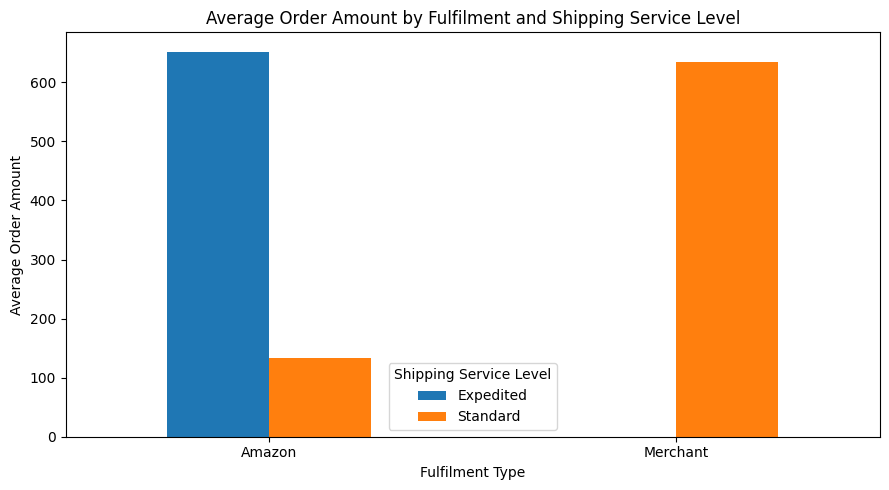

In [17]:
# Multivariate analysis:
# Average order amount by fulfilment and shipping service level

grouped_data = (
    df.groupby(["fulfilment", "ship_service_level"])["amount"]
      .mean()
      .reset_index()
)

display(grouped_data.round(2))

# Create grouped bar chart

pivot_data = grouped_data.pivot(
    index="fulfilment",
    columns="ship_service_level",
    values="amount"
)

pivot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Average Order Amount by Fulfilment and Shipping Service Level")
plt.xlabel("Fulfilment Type")
plt.ylabel("Average Order Amount")
plt.xticks(rotation=0)
plt.legend(title="Shipping Service Level")
plt.tight_layout()
plt.show()

### Multivariate Analysis – Interpretation

The analysis shows clear differences in average order value across fulfilment and shipping service combinations.

Amazon-fulfilled Expedited orders have an average order amount of 651.95, while Amazon-fulfilled Standard orders average 133.99. Merchant-fulfilled Standard orders have an average order amount of 634.01.

The results suggest that the relationship between order value, fulfilment type, and shipping service level varies considerably across the available combinations. The missing Merchant–Expedited combination indicates that this combination was not represented in the dataset.

## 11. Top 5 Critical Business Findings

### 1. Shipping service level is associated with order-value differences
The Mann–Whitney U test found a statistically significant difference in sales-amount distributions between Expedited and Standard orders (p < 0.05). Both groups have a median order value of ₹605, so the difference is in their overall distributions rather than their medians.

### 2. Fulfilment type is associated with order-value differences
Amazon-fulfilled and Merchant-fulfilled orders have statistically different sales-amount distributions (p = 0.000002). Both groups have a median order value of ₹605.

### 3. Merchant fulfilment has a higher cancellation rate
Merchant-fulfilled orders have a cancellation rate of 17.39%, compared with 12.57% for Amazon-fulfilled orders. The Chi-square test indicates that this difference is statistically significant (p < 0.05).

### 4. Order value varies substantially across fulfilment and service combinations
The multivariate analysis shows considerable differences in average order amount across the available fulfilment and shipping-service combinations. Amazon-fulfilled Expedited orders average ₹651.95, while Amazon-fulfilled Standard orders average ₹133.99.

### 5. The dataset contains strong concentration in major product categories
T-shirts and Shirts are the two largest product categories, with 28,348 and 28,110 records respectively. Together, they represent a substantial share of the dataset, indicating that these categories dominate the observed order volume.

## 12. Conclusion

The exploratory analysis identified meaningful patterns in order values, fulfilment methods, shipping service levels, and cancellation behaviour.

Statistical hypothesis testing showed significant associations between shipping service level and sales amount, fulfilment type and sales amount, and fulfilment type and cancellation status.

The analysis provides evidence that operational choices such as fulfilment method and shipping service level are associated with measurable differences in the observed retail data. These findings can support further investigation into fulfilment performance, cancellation reduction, and order-value optimization.

Statistical significance should not be interpreted as causation, and additional business data would be required to determine the underlying causes of these relationships.

In [18]:
# Final EDA validation

print("=== FINAL EDA CHECK ===")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nHypothesis testing completed:")
print("1. Service level vs sales amount ✅")
print("2. Fulfilment vs sales amount ✅")
print("3. Fulfilment vs cancellation rate ✅")

print("\nEDA analysis completed successfully! ✅")

=== FINAL EDA CHECK ===
Rows: 73699
Columns: 25
Missing values: 0
Duplicate rows: 0

Hypothesis testing completed:
1. Service level vs sales amount ✅
2. Fulfilment vs sales amount ✅
3. Fulfilment vs cancellation rate ✅

EDA analysis completed successfully! ✅
